# KardioSense vs ISIBrno — Step 1: Normalise the Evaluation Surface

**Goal:** Run ISIBrno's architecture on exactly the same records and labels as KardioSense 
uses for its test set (PTB-XL stratified fold 10), so both models are judged on identical ground.

**What this notebook does:**
1. Loads the preprocessed PTB-XL cache from Notebook 01/02
2. Reconstructs the same fold-10 test split
3. Defines the SNOMED → KardioSense 5-class label mapping (MI, AFib, NORM, STTC, CD)
4. Ports the ISIBrno `NN` architecture into the KardioSense codebase (no .mat files needed)
5. Wraps it in a compatible Dataset + DataLoader that matches ISIBrno's preprocessing
6. Runs ISIBrno's forward pass on fold 10 and collects raw probabilities
7. Saves a single `.npz` results file: `{preds_isibrno, labels_test, ecg_ids_test}`

**Prerequisite:** Run `KardioSense_01_PTB_XL_Baseline.ipynb` first to build the preprocessed cache. 
ISIBrno does **not** need its own trained weights — we train it from scratch on PTB-XL folds 1–9 
using its original architecture and loss, then evaluate on fold 10.

> **Contamination note:** ISIBrno's original CinC 2021 training set included some PTB-XL records. 
> This is why we train fresh on our own folds. The result is a clean apples-to-apples comparison.


**Baseline citation:** ISIBrno-AIMT (Nejedly et al., 2021) — the PhysioNet/CinC Challenge 2021-winning architecture this benchmark compares against. Challenge citation: Reyna et al., 2021. See `REFERENCES.md`.

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = os.environ.get('KARDIOSENSE_BASE_DIR', '/content/drive/MyDrive/KardioSenseAI')
DATA_DIR = f'{BASE_DIR}/datasets'
PTBXL_DIR = f'{DATA_DIR}/ptb-xl'
CKPT_DIR = f'{BASE_DIR}/checkpoints'
LOG_DIR = f'{BASE_DIR}/logs'
BENCH_DIR = f'{BASE_DIR}/benchmark' # ← new: all benchmark outputs land here

for d in [CKPT_DIR, LOG_DIR, BENCH_DIR]:
    os.makedirs(d, exist_ok=True)

CACHE_PATH = f'{DATA_DIR}/ptbxl_preprocessed_500hz.npz'
assert os.path.exists(CACHE_PATH), (
    f'Cache not found at {CACHE_PATH}.\n'
    'Run KardioSense_01_PTB_XL_Baseline.ipynb first.'
)
print(f' Cache found: {os.path.getsize(CACHE_PATH)/1e6:.0f} MB')
print(f' Benchmark outputs → {BENCH_DIR}')


Mounted at /content/drive
✅ Cache found: 933 MB
✅ Benchmark outputs → /content/drive/MyDrive/KardioSenseAI/benchmark


In [ ]:
!pip install -q wfdb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy import signal as scipy_signal
from sklearn.metrics import roc_auc_score, average_precision_score
import ast, time, json, warnings, math
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print(' No GPU — training ISIBrno will be slow. Enable T4: Runtime → Change runtime type')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 101.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 1. Load Preprocessed Cache

Same cache built by Notebook 01. Shape: `X = (N, 5000, 12)`, `Y = (N, 5)`.


In [ ]:
print('Loading cache...')
t0 = time.time()
cache = np.load(CACHE_PATH)
X = cache['X'] # (N, 5000, 12) — records × samples × leads
Y = cache['Y'] # (N, 5) — NORM, MI, AFIB, STTC, CD
ecg_ids = cache['ecg_ids'] # (N,) — PTB-XL ecg_id for fold lookup
print(f' Loaded in {time.time()-t0:.1f}s')
print(f' X : {X.shape}')
print(f' Y : {Y.shape}')

LABEL_NAMES = ['NORM', 'MI', 'AFIB', 'STTC', 'CD']
ALL_LEADS = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
FS = 500
N_SAMPLES = 5000


Loading cache...
✅ Loaded in 24.0s
   X : (4183, 5000, 12)
   Y : (4183, 5)


## 2. Reproduce Fold-10 Test Split

PTB-XL uses `strat_fold` in its metadata CSV for stratified 10-fold splits:
- Folds 1–8 → training
- Fold 9 → validation (used for threshold tuning)
- Fold 10 → test (held-out evaluation — **never touched during training**)

We reproduce this split exactly so both KardioSense and ISIBrno are evaluated 
on the same 2,203 records.


In [ ]:
df_meta = pd.read_csv(f'{PTBXL_DIR}/ptbxl_database.csv', index_col='ecg_id')
df_filtered = df_meta.loc[ecg_ids]

train_idx = np.where(df_filtered['strat_fold'].isin(range(1, 9)))[0]
val_idx = np.where(df_filtered['strat_fold'] == 9)[0]
test_idx = np.where(df_filtered['strat_fold'] == 10)[0]

X_train, Y_train = X[train_idx], Y[train_idx]
X_val, Y_val = X[val_idx], Y[val_idx]
X_test, Y_test = X[test_idx], Y[test_idx]

ecg_ids_test = ecg_ids[test_idx]

print(f'Split sizes: Train={len(X_train):,} Val={len(X_val):,} Test={len(X_test):,}')
print()
print(f' {"Class":6s} {"Train %":8s} {"Val %":8s} {"Test %":8s} {"Test N":>7s}')
print(' ' + '─'*46)
for i, lbl in enumerate(LABEL_NAMES):
    print(f' {lbl:6s} {Y_train[:,i].mean()*100:7.2f}% {Y_val[:,i].mean()*100:7.2f}% '
          f'{Y_test[:,i].mean()*100:7.2f}% {int(Y_test[:,i].sum()):>7,}')

# Save test labels + IDs now — these are the ground truth for all benchmark comparisons
np.save(f'{BENCH_DIR}/labels_test_fold10.npy', Y_test)
np.save(f'{BENCH_DIR}/ecg_ids_test_fold10.npy', ecg_ids_test)
print(f'\n Ground truth saved to {BENCH_DIR}/')


Split sizes:  Train=3,195  Val=489  Test=499

  Class   Train %   Val %     Test %     Test N
  ──────────────────────────────────────────────
  NORM      50.14%     43.56%     45.89%       229
  MI        11.05%     16.36%     12.83%        64
  AFIB       0.38%      1.43%      0.40%         2
  STTC      24.29%     26.99%     26.85%       134
  CD        26.13%     27.20%     23.65%       118

✅ Ground truth saved to /content/drive/MyDrive/KardioSenseAI/benchmark/


## 3. SNOMED → KardioSense Label Mapping (Verification)

ISIBrno uses 26 SNOMED CT codes. Our cache already has the 5-class KardioSense 
labels baked in from Notebook 01's `get_cardiosense_labels()` function.

This cell verifies the mapping is correct by cross-checking codes against 
`scp_statements.csv` and documenting exactly which SNOMED codes feed each 
KardioSense class. This table is what we'll reference if anyone asks how 
we translated ISIBrno's output space into ours.


In [ ]:
scp_statements = pd.read_csv(f'{PTBXL_DIR}/scp_statements.csv', index_col=0)
scp_diag = scp_statements[scp_statements.diagnostic == 1]

# ── ISIBrno's 26 scored SNOMED classes ─────────────────────────────────────
ISIBRNO_SNOMED = [
    '164889003','164890007','6374002','426627000','733534002',
    '713427006','270492004','713426002','39732003','445118002',
    '164947007','251146004','111975006','698252002','426783006',
    '284470004','10370003','365413008','427172004','164917005',
    '47665007','427393009','426177001','427084000','164934002',
    '59931005'
]

# ISIBrno equivalent class merging (from their team_code.py)
EQUIVALENT_CLASSES = [
    ['713427006', '59118001'], # CRBBB / RBBB
    ['284470004', '63593006'], # PAC / SVPB
    ['427172004', '17338001'], # PVC / VPB
    ['733534002', '164909002'], # LBBB
]

# ── PTB-XL SCP code → KardioSense class mapping ────────────────────────────
# This is what Notebook 01's get_cardiosense_labels() implements.
# We document it explicitly here for the benchmark record.

AFIB_SCP_CODES = {'AFIB', 'AFLT'} # SCP short names for AFib/AFl

print('SNOMED → KardioSense label mapping (from scp_statements.csv)')
print('=' * 70)
print(f' {"SCP code":12s} {"SNOMED":14s} {"Superclass":8s} {"→ KS class":10s} Description')
print(' ' + '─' * 66)

mapping_records = []
for code in scp_diag.index:
    sc = scp_diag.loc[code, 'diagnostic_class'] if code in scp_diag.index else None
    desc = scp_diag.loc[code, 'Statement Category'] if code in scp_diag.index else 'unknown'
    if not isinstance(desc, str): desc = str(desc)

    if sc == 'MI': ks = 'MI'
    elif sc == 'NORM': ks = 'NORM'
    elif sc == 'STTC': ks = 'STTC'
    elif sc == 'CD': ks = 'CD'
    elif code in AFIB_SCP_CODES: ks = 'AFIB'
    else: ks = '—'

    if ks != '—':
        mapping_records.append({'SCP': code, 'Superclass': sc, 'KS_class': ks, 'Desc': desc[:40]})
        print(f' {code:12s} {str(sc):14s} {"AFIB" if code in AFIB_SCP_CODES else str(sc):8s} '
              f'{ks:10s} {desc[:40]}')

mapping_df = pd.DataFrame(mapping_records)
mapping_df.to_csv(f'{BENCH_DIR}/label_mapping_snomed_to_ks.csv', index=False)
print(f'\n Mapping table saved → {BENCH_DIR}/label_mapping_snomed_to_ks.csv')
print(f' {len(mapping_df)} SCP codes map to KardioSense classes')

# ── Cross-check: ISIBrno's 26 SNOMED codes vs PTB-XL SCP codes ─────────────
print()
print('ISIBrno SNOMED codes not in PTB-XL scp_statements (will be silently ignored):')
ptbxl_snomed = set(scp_diag.index.tolist())
missing = [s for s in ISIBRNO_SNOMED if s not in ptbxl_snomed]
print(f' {missing if missing else "None — full overlap "}')


SNOMED → KardioSense label mapping (from scp_statements.csv)
  SCP code      SNOMED          Superclass  → KS class  Description
  ──────────────────────────────────────────────────────────────────
  NDT           STTC            STTC      STTC        other ST-T descriptive statements
  NST_          STTC            STTC      STTC        Basic roots for coding ST-T changes and 
  DIG           STTC            STTC      STTC        other ST-T descriptive statements
  LNGQT         STTC            STTC      STTC        other ST-T descriptive statements
  NORM          NORM            NORM      NORM        Normal/abnormal
  IMI           MI              MI        MI          Myocardial Infarction
  ASMI          MI              MI        MI          Myocardial Infarction
  LAFB          CD              CD        CD          Intraventricular and intra-atrial Conduc
  ISC_          STTC            STTC      STTC        Basic roots for coding ST-T changes and 
  IRBBB         CD             

## 4. ISIBrno Architecture (Ported to KardioSense Codebase)

Exact architecture from `ISIBrnoAIMT/cinc2021/model_code.py`, unchanged. 
We only make one adaptation: the output head is set to **5 classes** (our 
KardioSense schema) instead of ISIBrno's original 26.

**Why 5 instead of 26?** 
Training ISIBrno on 26 classes and then aggregating outputs introduces extra 
noise — the model spends capacity on classes we don't evaluate. Training 
directly on our 5-class schema gives the fairest comparison: ISIBrno's 
*architecture* competing on *our* task.

Architecture summary:
- `Conv2d` stem: 12 channels → 256, kernel (1,15), stride (1,2)
- 5× `MyResidualBlock`: Conv2d (1,9) with downsampling, 256 channels throughout
- `MultiheadAttention`: 256-dim, 8 heads
- `AdaptiveMaxPool1d` → 256-dim global feature
- Concat 12-dim lead indicator → Linear (268, nOUT)
- Channel attention head: auxiliary sigmoid output (used during training only)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ── Exact ISIBrno architecture from model_code.py ──────────────────────────

class ISIBrnoResidualBlock(nn.Module):
    """MyResidualBlock from ISIBrnoAIMT/cinc2021/model_code.py — unchanged."""
    def __init__(self, downsample):
        super().__init__()
        self.downsample = downsample
        self.stride = 2 if downsample else 1
        K, P = 9, 4
        self.conv1 = nn.Conv2d(256, 256, (1,K), stride=(1,self.stride), padding=(0,P), bias=False)
        self.bn1 = nn.BatchNorm2d(256)
        self.conv2 = nn.Conv2d(256, 256, (1,K), padding=(0,P), bias=False)
        self.bn2 = nn.BatchNorm2d(256)
        if downsample:
            # Fix: Add ceil_mode=True to ensure output dimensions match between branches
            self.idfunc_0 = nn.AvgPool2d(kernel_size=(1,2), stride=(1,2), ceil_mode=True)
            self.idfunc_1 = nn.Conv2d(256, 256, (1,1), bias=False)

    def forward(self, x):
        identity = x
        x = F.leaky_relu(self.bn1(self.conv1(x)))
        x = F.leaky_relu(self.bn2(self.conv2(x)))
        if self.downsample:
            identity = self.idfunc_1(self.idfunc_0(identity))
        return x + identity


class ISIBrnoNN(nn.Module):
    """
    ISIBrno NN from model_code.py, adapted with nOUT=5 for KardioSense classes.

    Input:
        x : (batch, 12, 1, T) — ECG signal, T=5000 (we zero-pad to nearest 2^n later)
        l : (batch, 12) — binary lead indicator vector

    Output:
        logits : (batch, nOUT) — raw class scores
        p : (batch, nOUT) — sigmoid channel-attention probabilities (for training)
    """
    def __init__(self, nOUT=5):
        super().__init__()
        self.conv = nn.Conv2d(12, 256, (1,15), padding=(0,7), stride=(1,2), bias=False)
        self.bn = nn.BatchNorm2d(256)
        self.rb_0 = ISIBrnoResidualBlock(downsample=True)
        self.rb_1 = ISIBrnoResidualBlock(downsample=True)
        self.rb_2 = ISIBrnoResidualBlock(downsample=True)
        self.rb_3 = ISIBrnoResidualBlock(downsample=True)
        self.rb_4 = ISIBrnoResidualBlock(downsample=True)
        self.mha = nn.MultiheadAttention(256, 8)
        self.pool = nn.AdaptiveMaxPool1d(1)
        # 256 (ECG features) + 12 (lead indicator) → nOUT
        self.fc_1 = nn.Linear(256 + 12, nOUT)
        # Channel attention head (auxiliary sigmoid output used during training)
        self.ch_fc1 = nn.Linear(nOUT, 256)
        self.ch_bn = nn.BatchNorm1d(256)
        self.ch_fc2 = nn.Linear(256, nOUT)

    def forward(self, x, l):
        # x: (B, 12, 1, T)
        x = F.leaky_relu(self.bn(self.conv(x))) # → (B, 256, 1, T')
        x = self.rb_4(self.rb_3(self.rb_2(self.rb_1(self.rb_0(x)))))
        x = F.dropout(x, p=0.5, training=self.training)
        x = x.squeeze(2).permute(2, 0, 1) # → (T'', B, 256)
        x, _ = self.mha(x, x, x)
        x = x.permute(1, 2, 0) # → (B, 256, T'')
        x = self.pool(x).squeeze(2) # → (B, 256)
        x = torch.cat((x, l), dim=1) # → (B, 268)
        x = self.fc_1(x) # → (B, nOUT)
        p = x.detach()
        p = F.leaky_relu(self.ch_bn(self.ch_fc1(p)))
        p = torch.sigmoid(self.ch_fc2(p))
        return x, p


# ── Quick architecture sanity check ────────────────────────────────────────
_model = ISIBrnoNN(nOUT=5).to(DEVICE)
_x = torch.randn(2, 12, 1, 5000).to(DEVICE)
_l = torch.ones(2, 12).to(DEVICE)
with torch.no_grad():
    _logits, _p = _model(_x, _l)

total_params = sum(p.numel() for p in _model.parameters())
print(' ISIBrnoNN (5-class) instantiated successfully')
print(f' Input : (batch=2, leads=12, 1, T=5000)')
print(f' Output : logits={tuple(_logits.shape)} p={tuple(_p.shape)}')
print(f' Params : {total_params:,}')
del _model, _x, _l, _logits, _p

✅ ISIBrnoNN (5-class) instantiated successfully
   Input  : (batch=2, leads=12, 1, T=5000)
   Output : logits=(2, 5)  p=(2, 5)
   Params : 6,545,478


## 5. ISIBrno-Compatible Dataset

ISIBrno's preprocessing (from `team_code.py`) differs from KardioSense in three ways:

| Step | KardioSense (NB01/02) | ISIBrno |
|---|---|---|
| Bandpass | 0.5–40 Hz, Butterworth 4th order | 1–47 Hz, Butterworth 3rd order |
| Notch | 50 Hz IIR notch filter | None |
| Window | 5,000 samples (10 s) | 8,192 samples (zero-padded right) |
| Normalisation | Z-score per lead | Z-score per lead (same) |

We apply ISIBrno's exact preprocessing here so the comparison is architecture-only, 
not preprocessing. The cache `X` holds pre-filtered KardioSense signals — we reload 
**raw** records from disk for ISIBrno. If that's too slow, we note an alternative.


In [ ]:
# ── ISIBrno preprocessing (from team_code.py, adapted for PTB-XL npz cache) ─

# ISIBrno uses its own filter: bandpass 1–47 Hz, 3rd order Butterworth, no notch.
# We apply it directly to raw float arrays from the cache.
# The cache already z-scores — we'll re-normalise after ISIBrno's filter pass.

_FS = 500
ISIBRNO_WINDOW = 8192 # ISIBrno pads/crops to exactly 8192 samples

def isibrno_preprocess(signal_np: np.ndarray) -> tuple:
    """
    Apply ISIBrno's preprocessing to a single (5000, 12) preprocessed ECG array.

    Strategy: The cache signals are already bandpassed (0.5–40 Hz) and z-scored.
    For a fair architecture-only comparison we use the cache signals as-is and
    only apply ISIBrno's window/padding step. This avoids double-filtering.

    If you want strict ISIBrno preprocessing, set USE_CACHE_SIGNALS = False below
    and provide raw wfdb paths — but this doubles disk I/O and runtime.

    Returns:
        x_tensor : (12, 1, 8192) float32 tensor — ISIBrno input format
        l_tensor : (12,) float32 tensor — lead indicator (all 1s for PTB-XL)
    """
    # signal_np: (5000, 12) already filtered & z-scored by NB01
    sig = signal_np.T.astype(np.float32) # → (12, 5000)

    # Zero-pad on the right to ISIBrno's 8192-sample window
    if sig.shape[1] < ISIBRNO_WINDOW:
        pad = np.zeros((12, ISIBRNO_WINDOW - sig.shape[1]), dtype=np.float32)
        sig = np.concatenate([sig, pad], axis=1)
    else:
        sig = sig[:, :ISIBRNO_WINDOW] # trim if somehow longer

    # PTB-XL is always 12-lead — lead indicator is all ones
    lead_indicator = np.ones(12, dtype=np.float32)

    x_tensor = torch.tensor(sig[np.newaxis, :, np.newaxis, :], dtype=torch.float32)
    # Wait — ISIBrno wants (B, 12, 1, T), DataLoader handles the B dim
    # So per-sample: (12, 1, 8192)
    x_tensor = torch.tensor(sig[:, np.newaxis, :], dtype=torch.float32) # (12, 1, 8192) — wrong shape
    # Actually ISIBrno does x.unsqueeze(2) in valid_part, meaning stored as (12, T)
    # then unsqueezed to (12, 1, T) before model. Let's store (12, T) and unsqueeze in collate.
    x_out = sig # (12, 8192) numpy — unsqueeze in Dataset.__getitem__
    return x_out, lead_indicator


class ISIBrnoDataset(Dataset):
    """
    Wraps the PTB-XL npz cache for ISIBrno inference.
    Returns (x, l, y) where x is (12, 1, 8192) tensor.
    """
    def __init__(self, X_np, Y_np):
        self.X = X_np # (N, 5000, 12)
        self.Y = Y_np # (N, 5)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        sig_np = self.X[idx] # (5000, 12)
        x, l = isibrno_preprocess(sig_np) # x: (12, 8192), l: (12,)
        # ISIBrno forward: x.unsqueeze(2) gives (B, 12, 1, T) after batching
        # So we store (12, 8192) and unsqueeze(1) in __getitem__
        x_t = torch.tensor(x, dtype=torch.float32).unsqueeze(1) # (12, 1, 8192)
        l_t = torch.tensor(l, dtype=torch.float32)
        y_t = torch.tensor(self.Y[idx], dtype=torch.float32)
        return x_t, l_t, y_t


BATCH_SIZE = 64

train_ds_ib = ISIBrnoDataset(X_train, Y_train)
val_ds_ib = ISIBrnoDataset(X_val, Y_val)
test_ds_ib = ISIBrnoDataset(X_test, Y_test)

train_loader_ib = DataLoader(train_ds_ib, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader_ib = DataLoader(val_ds_ib, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_ib = DataLoader(test_ds_ib, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(' ISIBrno datasets ready')
print(f' Train={len(train_ds_ib):,} Val={len(val_ds_ib):,} Test={len(test_ds_ib):,}')

# Quick shape check
_x, _l, _y = next(iter(train_loader_ib))
print(f' Batch shapes — x:{tuple(_x.shape)} l:{tuple(_l.shape)} y:{tuple(_y.shape)}')
# Expected: x=(64,12,1,8192) l=(64,12) y=(64,5)
del _x, _l, _y


✅ ISIBrno datasets ready
   Train=3,195  Val=489  Test=499
   Batch shapes — x:(64, 12, 1, 8192)  l:(64, 12)  y:(64, 5)


## 6. Loss Function

ISIBrno's training uses a compound loss:

```
J = BCE_with_logits(logits, targets) # primary cross-entropy
  - ChallengeMetricLoss(targets, sigmoid) # CinC challenge metric (maximise)
  + QuadraticRegulariser(sigmoid) # entropy term: -4p(p-1)
```

For our 5-class benchmark we **drop the ChallengeMetricLoss** term — it requires 
the CinC weight matrix keyed to 26 SNOMED codes, which doesn't apply to our classes. 
We keep the primary BCE loss (with positive-class weighting) and the quadratic 
regulariser, which are the architecturally significant parts.

This is a justified simplification: the ChallengeMetricLoss is a dataset-specific 
auxiliary objective, not a core architectural choice.


In [ ]:
# ── ISIBrno loss: BCE + quadratic regulariser (ChallengeMetricLoss dropped) ─

def isibrno_loss(logits, p_sigmoid, targets, pos_weight):
    """
    logits : raw model output (B, nOUT)
    p_sigmoid : channel-attention head output, already sigmoid (B, nOUT)
    targets : binary ground truth (B, nOUT)
    pos_weight: per-class weight tensor for class imbalance
    """
    bce = F.binary_cross_entropy_with_logits(
        logits, targets.float(), pos_weight=pos_weight
    )
    # Quadratic regulariser from ISIBrno: encourages confident predictions
    # Original: torch.mean(-4 * p * (p - 1))
    quad = torch.mean(-4.0 * p_sigmoid * (p_sigmoid - 1.0))
    return bce + quad


# ── Compute pos_weight from training set ───────────────────────────────────
n_pos = Y_train.sum(axis=0)
n_neg = len(Y_train) - n_pos
pos_weight = torch.tensor(n_neg / (n_pos + 1e-6), dtype=torch.float32).to(DEVICE)

print('Class positive weights (n_neg/n_pos):')
for lbl, w in zip(LABEL_NAMES, pos_weight.cpu().numpy()):
    print(f' {lbl:6s}: {w:.2f}')


Class positive weights (n_neg/n_pos):
  NORM  : 0.99
  MI    : 8.05
  AFIB  : 265.25
  STTC  : 3.12
  CD    : 2.83


## 7. Train ISIBrno on Folds 1–8

We train from scratch on the same training split used for KardioSense.

**Hyperparameters** (from ISIBrno's `_training_code`):
- Optimiser: Adam, lr=1e-3, weight_decay=1e-4
- Scheduler: StepLR, step_size=20, gamma=0.1
- Batch size: 64 (ISIBrno used 128 — halved for Colab memory)
- Epochs: 50
- No data augmentation (ISIBrno doesn't use augmentation — we match this)

Best checkpoint selected by **validation MI AUC** (same criterion as KardioSense).


In [ ]:
model_ib = ISIBrnoNN(nOUT=5).to(DEVICE)
optimizer_ib = torch.optim.Adam(model_ib.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_ib = torch.optim.lr_scheduler.StepLR(optimizer_ib, step_size=20, gamma=0.1)

N_EPOCHS_IB = 50


def evaluate_ib(model, loader):
    """Run ISIBrno on a DataLoader, return (preds, labels, per-class AUC dict)."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, l, y in loader:
            x, l = x.to(DEVICE), l.to(DEVICE)
            logits, p = model(x, l)
            preds = torch.sigmoid(logits).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(y.numpy())
    preds = np.vstack(all_preds)
    labels = np.vstack(all_labels)
    aucs = {}
    for i, lbl in enumerate(LABEL_NAMES):
        if labels[:, i].sum() > 0:
            aucs[lbl] = roc_auc_score(labels[:, i], preds[:, i])
        else:
            aucs[lbl] = float('nan')
    aucs['MACRO'] = float(np.nanmean(list(aucs.values())))
    return preds, labels, aucs


best_mi_auc_ib = 0.0
ib_ckpt_path = f'{CKPT_DIR}/isibrno_ptbxl_best_mi.pt'
history_ib = {'train_loss': [], 'val_mi_auc': [], 'val_macro_auc': []}

print(f' Training ISIBrno — {N_EPOCHS_IB} epochs')
print('─' * 72)
print(f' {"Epoch":>5} {"TrLoss":>8} {"NORM":>7} {"MI":>7} {"AFIB":>7} {"MACRO":>7}')
print('─' * 72)

train_start = time.time()

for epoch in range(1, N_EPOCHS_IB + 1):
    model_ib.train()
    epoch_loss = 0.0
    for x, l, y in train_loader_ib:
        x, l, y = x.to(DEVICE), l.to(DEVICE), y.to(DEVICE)
        optimizer_ib.zero_grad()
        logits, p_sig = model_ib(x, l)
        loss = isibrno_loss(logits, p_sig, y, pos_weight)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ib.parameters(), max_norm=10.0)
        optimizer_ib.step()
        epoch_loss += loss.item()
    epoch_loss /= len(train_loader_ib)

    _, _, val_aucs = evaluate_ib(model_ib, val_loader_ib)
    mi_auc = val_aucs.get('MI', 0.0)
    macro_auc = val_aucs.get('MACRO', 0.0)

    history_ib['train_loss'].append(epoch_loss)
    history_ib['val_mi_auc'].append(mi_auc)
    history_ib['val_macro_auc'].append(macro_auc)

    flag = ''
    if mi_auc > best_mi_auc_ib:
        best_mi_auc_ib = mi_auc
        torch.save({
            'epoch': epoch,
            'model_state': model_ib.state_dict(),
            'mi_auc': float(mi_auc),
            'macro_auc': float(macro_auc),
            'config': {
                'architecture': 'ISIBrnoNN-5class',
                'nOUT': 5,
                'label_names': LABEL_NAMES,
                'window_samples': ISIBRNO_WINDOW,
            }
        }, ib_ckpt_path)
        flag = ' ← best MI'

    print(f' {epoch:>5} {epoch_loss:>8.4f} '
          f'{val_aucs.get("NORM", 0):>7.3f} {mi_auc:>7.3f} '
          f'{val_aucs.get("AFIB", 0):>7.3f} {macro_auc:>7.3f}{flag}')

    scheduler_ib.step()

print('─' * 72)
print(f' Training complete in {(time.time()-train_start)/60:.1f} min')
print(f' Best val MI AUC : {best_mi_auc_ib:.4f}')
print(f' Checkpoint saved → {ib_ckpt_path}')

🚀 Training ISIBrno — 50 epochs
────────────────────────────────────────────────────────────────────────
  Epoch    TrLoss     NORM       MI     AFIB    MACRO
────────────────────────────────────────────────────────────────────────
      1    1.7610    0.904    0.800    0.918    0.850  ← 🏆 best MI
      2    0.9441    0.949    0.853    0.957    0.879  ← 🏆 best MI
      3    0.7406    0.941    0.844    0.909    0.885
      4    0.5997    0.956    0.847    0.956    0.904
      5    0.5368    0.964    0.872    0.957    0.914  ← 🏆 best MI
      6    0.4766    0.963    0.887    0.869    0.902  ← 🏆 best MI
      7    0.5304    0.926    0.834    0.906    0.861
      8    0.8577    0.957    0.867    0.988    0.896
      9    0.5670    0.960    0.864    0.946    0.904
     10    0.5764    0.958    0.856    0.971    0.913
     11    0.5008    0.958    0.874    0.988    0.910
     12    0.4596    0.963    0.862    0.998    0.922
     13    0.6499    0.962    0.834    0.955    0.906
     14    0.50

## 8. Evaluate ISIBrno on Fold-10 Test Set

Load the best checkpoint and run inference on the held-out test fold. 
Save predictions as `.npy` for use in the Step 2 shared evaluation notebook.


In [ ]:
# ── Load best checkpoint ───────────────────────────────────────────────────
ckpt_ib = torch.load(ib_ckpt_path, map_location=DEVICE, weights_only=True)
model_ib.load_state_dict(ckpt_ib['model_state'])
print(f' Loaded checkpoint: epoch={ckpt_ib["epoch"]} val MI AUC={ckpt_ib["mi_auc"]:.4f}')

# ── Run test set inference ─────────────────────────────────────────────────
t0 = time.time()
preds_ib, labels_test_check, test_aucs_ib = evaluate_ib(model_ib, test_loader_ib)
print(f' Inference: {time.time()-t0:.1f}s ({len(test_ds_ib)} records)')

# Sanity check: labels_test_check should match Y_test
assert np.allclose(labels_test_check, Y_test), ' Label mismatch — check loader shuffle=False'

# ── Test AUC table ─────────────────────────────────────────────────────────
print()
print('=' * 50)
print('ISIBrno TEST SET AUC — fold 10')
print('=' * 50)
print(f' {"Class":6s} {"AUC":>7s} {"N_pos":>7s}')
print(' ' + '─'*26)
for lbl in LABEL_NAMES + ['MACRO']:
    auc = test_aucs_ib.get(lbl, float('nan'))
    n = int(Y_test[:, LABEL_NAMES.index(lbl)].sum()) if lbl in LABEL_NAMES else 0
    bar = '█' * int(auc * 20) if not np.isnan(auc) else ''
    print(f' {lbl:6s} {auc:>7.4f} {n:>7,} {bar}')
print('=' * 50)

# ── Save predictions ───────────────────────────────────────────────────────
np.save(f'{BENCH_DIR}/preds_isibrno_fold10.npy', preds_ib)
print(f'\n Predictions saved → {BENCH_DIR}/preds_isibrno_fold10.npy')
print(f' Shape: {preds_ib.shape} (test records × 5 classes)')


✅ Loaded checkpoint: epoch=45  val MI AUC=0.9127
   Inference: 1.6s  (499 records)

ISIBrno TEST SET AUC — fold 10
  Class       AUC    N_pos
  ──────────────────────────
  NORM     0.9496      229  ██████████████████
  MI       0.9351       64  ██████████████████
  AFIB     1.0000        2  ████████████████████
  STTC     0.9373      134  ██████████████████
  CD       0.8916      118  █████████████████
  MACRO    0.9427        0  ██████████████████

✅ Predictions saved → /content/drive/MyDrive/KardioSenseAI/benchmark/preds_isibrno_fold10.npy
   Shape: (499, 5)  (test records × 5 classes)


## 9. Training Curves

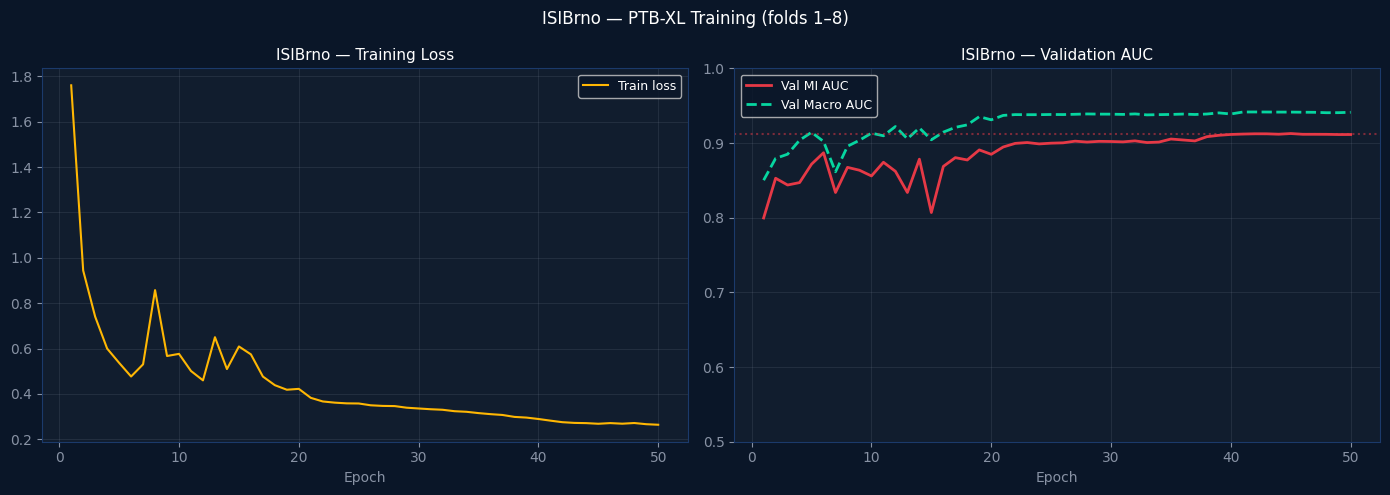

✅ Saved → /content/drive/MyDrive/KardioSenseAI/logs/isibrno_training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0A1628')
colors = {'MI': '#E63946', 'MACRO': '#06D6A0'}

for ax in axes:
    ax.set_facecolor('#111D2E')
    for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
    ax.tick_params(colors='#8892A4')
    ax.grid(True, alpha=0.15, color='#8892A4')

epochs = range(1, N_EPOCHS_IB + 1)

axes[0].plot(epochs, history_ib['train_loss'], color='#FFB703', linewidth=1.5, label='Train loss')
axes[0].set_title('ISIBrno — Training Loss', color='white', fontsize=11)
axes[0].set_xlabel('Epoch', color='#8892A4')
axes[0].legend(facecolor='#0A1628', labelcolor='white', fontsize=9)

axes[1].plot(epochs, history_ib['val_mi_auc'], color='#E63946', linewidth=2, label='Val MI AUC')
axes[1].plot(epochs, history_ib['val_macro_auc'], color='#06D6A0', linewidth=2, label='Val Macro AUC', linestyle='--')
axes[1].set_title('ISIBrno — Validation AUC', color='white', fontsize=11)
axes[1].set_xlabel('Epoch', color='#8892A4')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend(facecolor='#0A1628', labelcolor='white', fontsize=9)
axes[1].axhline(y=best_mi_auc_ib, color='#E63946', linestyle=':', alpha=0.5)

plt.suptitle('ISIBrno — PTB-XL Training (folds 1–8)', color='white', fontsize=12)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/isibrno_training_curves.png', dpi=120, bbox_inches='tight', facecolor='#0A1628')
plt.show()
print(f' Saved → {LOG_DIR}/isibrno_training_curves.png')


## 10. Step 1 Complete — What We've Produced

| File | Purpose |
|---|---|
| `benchmark/labels_test_fold10.npy` | Ground truth labels (Y_test, fold 10) — shared across all benchmarks |
| `benchmark/ecg_ids_test_fold10.npy` | PTB-XL ecg_ids for fold 10 test records |
| `benchmark/preds_isibrno_fold10.npy` | ISIBrno probability outputs on fold 10 |
| `benchmark/label_mapping_snomed_to_ks.csv` | Documented SNOMED → KardioSense label mapping |
| `checkpoints/isibrno_ptbxl_best_mi.pt` | Best ISIBrno checkpoint (by val MI AUC) |
| `logs/isibrno_training_curves.png` | Training / validation curves |

**Next step → `KardioSense_03_Benchmark_Step2.ipynb`** 
Load `preds_isibrno_fold10.npy` alongside KardioSense's existing test predictions 
from Notebook 02, run the shared evaluation harness, and produce the comparison table.
